# Three classes: a pin that pays off now, a pin that pays off next move, and a pin that doesn't pay off

The distance notebook asked a binary question four times over — *is this a relevant
pin?*, scored separately in each distance bucket. This one asks a single **three-way**
question of one classifier:

> never relevant · relevant at **d=0** · relevant at **d=1**

Every position in the cohort holds one sustained absolute pin — `build_dataset.py`
selects for exactly that — so the negative class is **a pin that never becomes
load-bearing**, not a position without a pin. The question is relevance throughout,
never presence.

`d=2` and `d=3` are dropped. They hold 1,701 positives between them, not enough to be a
third and fourth class next to 15,138 and 8,987.

| | |
|---|---|
| **Probed position** | P0 — the board the solver sees |
| **Layer** | `acc||tacc` (the sweep's best), `MLPClassifier(512,128)` — the distance notebook's layer, kept so the two read together |
| **Classes** | `negative` (pin present, no `pin` theme, tagger never fires) · `d=0` · `d=1` |
| **Negatives** | length-matched to the pooled positives, so the negative class is not readable off puzzle length |
| **Readout** | 5-fold out-of-fold predictions, argmax → confusion matrix |

Two arms, side by side:

- **max samples** — every d=0 and every d=1 the cohort has, negatives 1:1 against the two together.
- **uniform** — 8,987 per class, the size of the smallest.

## What is matched, and what deliberately is not

The negative class is length-matched, for the reason the distance notebook gives: without
it a probe can pick the negatives out on *"this is a short, simple puzzle"* rather than on
the position.

**`d=0` against `d=1` is not matched, and cannot be.** A puzzle cannot have `d=1` unless
it is at least two solver moves long, so the two classes have different length
distributions by construction (`d=0` mean 1.64 moves, `d=1` mean 2.13). Any `d=0` vs
`d=1` cell in the matrix below therefore has puzzle length available to it as well as the
position. That correlation is part of what the distance question *is*, not a confound to
partial out.

## 1 · Configuration

In [1]:
from pathlib import Path
import os, sys

_pylibs = Path.cwd().parent / ".pylibs"
if _pylibs.is_dir() and str(_pylibs) not in sys.path:
    sys.path.insert(0, str(_pylibs))
sys.path.insert(0, str(Path.cwd()))

HERE     = Path.cwd()
DUMP     = Path(os.environ.get("SF_PROBE_DUMP",  HERE / "data" / "dump.bin"))
META     = Path(os.environ.get("SF_PROBE_META",  HERE / "data" / "meta.tsv"))
RELEV    = Path(os.environ.get("SF_PROBE_RELEV", HERE / "data" / "relevance.tsv"))
SEED, FOLDS = 0, 5
LAYER = "acc||tacc"          # the sweep's most readable representation (§7 there)

# Artifacts are named after the layer, and `acc||tacc` — the sweep's best — is the
# default, so it keeps the unsuffixed names. Any other layer gets a suffix, which is
# what stops one layer's run overwriting another's.
TAG      = "" if LAYER == "acc||tacc" else "_" + LAYER.replace("||", "_")
SLUG     = LAYER.replace("||", "_")
OUT_JSON = HERE / f"results_3class{TAG}.json"
OUT_CSV  = HERE / f"results_3class{TAG}.csv"
PLOT     = HERE / f"confusion_3class{TAG}.png"
CACHE    = HERE / "data" / f"oof_3class_{SLUG}.npz"   # fold predictions; plot re-runs alone

# The same probe as everywhere else in sf-probe. sklearn switches to softmax on its own
# once the label vector has three values, so nothing here changes for multiclass.
MLP = dict(
    hidden_layer_sizes=(512, 128), activation="relu", solver="adam", alpha=1e-4,
    batch_size=512, learning_rate_init=1e-3, max_iter=200, early_stopping=True,
    n_iter_no_change=15, validation_fraction=0.1, random_state=SEED,
)

NEG, D0, D1 = 0, 1, 2                     # class codes
NAMES = {NEG: "negative", D0: "d=0", D1: "d=1"}
DRAW_SEED = SEED                          # the negative / subsample draw

print(f"dump {DUMP}  ({DUMP.stat().st_size/2**30:.2f} GB)")

dump /home/rharvey/Dokumente/Programmieren/xai-chess/sf-probe/data/dump.bin  (1.52 GB)


## 2 · Load — activations, labels, distances

In [2]:
import csv, numpy as np
from nnue_np import load, probe_matrix

acts = load(str(DUMP))                       # memmap — nothing read yet

with open(META) as fh:
    r = csv.reader(fh, delimiter="\t"); hdr = next(r); rows_meta = list(r)
col    = {k: i for i, k in enumerate(hdr)}
pid    = [x[col["puzzle_id"]] for x in rows_meta]
y_all  = np.array([int(x[col["label"]])        for x in rows_meta], np.int8)
rating = np.array([int(x[col["rating"]])       for x in rows_meta], np.int32)
nmoves = np.array([int(x[col["solver_moves"]]) for x in rows_meta], np.int8)

rel = {}
with open(RELEV) as fh:
    r = csv.reader(fh, delimiter="\t"); next(r)
    for row in r:
        rel[row[0]] = (int(row[2]), int(row[5]))      # distance, agree
assert set(pid) <= set(rel), "relevance.tsv does not cover every puzzle in meta.tsv"

dist  = np.array([rel[p][0] for p in pid], np.int8)   # -1 where the tagger never fires
agree = np.array([rel[p][1] for p in pid], bool)
assert len(acts) == len(y_all), f"{len(acts)} records vs {len(y_all)} labels"

# The cohort is the same as the distance notebook's: the two taggers agree.
y, d, rr, nn = y_all[agree], dist[agree], rating[agree], nmoves[agree]
N_COHORT = len(y)

print(f"dataset   {len(y_all):,}")
print(f"cohort    {N_COHORT:,} (taggers agree)")
for c, m in ((D0, (y == 1) & (d == 0)), (D1, (y == 1) & (d == 1))):
    print(f"  {NAMES[c]:<9} {m.sum():>7,}   mean rating {rr[m].mean():>6.0f}   "
          f"mean length {nn[m].mean():.2f}")
print(f"  {'negative':<9} {(y == 0).sum():>7,}   mean rating {rr[y == 0].mean():>6.0f}   "
      f"mean length {nn[y == 0].mean():.2f}")
print(f"  dropped d>=2  {((y == 1) & (d >= 2)).sum():>4,}")

dataset   151,614
cohort    131,634 (taggers agree)
  d=0        15,138   mean rating   1531   mean length 1.64
  d=1         8,987   mean rating   1667   mean length 2.13
  negative  105,789   mean rating   1635   mean length 2.07
  dropped d>=2  1,720


## 3 · The negative pool, by puzzle length

Both arms draw their negatives from this pool, at the lengths the positives have. The
right-hand column is the headroom: how many negatives exist per positive that needs one.

In [3]:
POS_ALL = np.flatnonzero((y == 1) & ((d == 0) | (d == 1)))
print(f"{'length':>7}{'d=0':>8}{'d=1':>8}{'pooled':>9}{'neg pool':>10}{'pool/pos':>10}")
for k in range(1, int(nn.max()) + 1):
    n0 = int(((y == 1) & (d == 0) & (nn == k)).sum())
    n1 = int(((y == 1) & (d == 1) & (nn == k)).sum())
    pool = int(((y == 0) & (nn == k)).sum())
    if n0 + n1 + pool == 0:
        continue
    ratio = pool / (n0 + n1) if n0 + n1 else float("inf")
    print(f"{k:>7}{n0:>8}{n1:>8}{n0+n1:>9}{pool:>10}{ratio:>10.2f}")
print(f"\npooled positives {len(POS_ALL):,}   negatives needed 1:1 {len(POS_ALL):,}")

 length     d=0     d=1   pooled  neg pool  pool/pos
      1    7861       0     7861     18797      2.39
      2    5210    7988    13198     64239      4.87
      3    1740     866     2606     19702      7.56
      4     260     115      375      2547      6.79
      5      53      14       67       409      6.10
      6      11       2       13        69      5.31
      7       3       1        4        19      4.75
      8       0       1        1         4      4.00
      9       0       0        0         3       inf

pooled positives 24,125   negatives needed 1:1 24,125


## 4 · The two arms

`draw_negatives(pos, n, rng)` takes `n` negatives whose `solver_moves` histogram is the
histogram of `pos`, scaled to `n` by largest remainder. At `n == len(pos)` that is exactly
the 1:1 pairing the distance notebook uses; below it, it thins every length by the same
factor rather than dropping whole lengths.

| arm | d=0 | d=1 | negative | rows |
|---|---|---|---|---|
| max samples | all 15,138 | all 8,987 | 24,125 | 48,250 |
| uniform | 8,987 sampled | all 8,987 | 8,987 | 26,961 |

In [4]:
def draw_negatives(pos, n, rng):
    '''Draw n negatives with the solver_moves histogram of `pos`, without replacement.'''
    lens, want = np.unique(nn[pos], return_counts=True)
    exact = want * (n / want.sum())
    take  = np.floor(exact).astype(int)
    short = n - take.sum()
    if short:                                    # largest remainder
        order = np.argsort(-(exact - take))
        take[order[:short]] += 1
    out = []
    for L, k in zip(lens, take):
        if k == 0:
            continue
        pool = np.flatnonzero((y == 0) & (nn == L))
        assert len(pool) >= k, f"length {L}: need {k} negatives, pool has {len(pool)}"
        out.append(rng.choice(pool, k, replace=False))
    out = np.concatenate(out)
    assert len(out) == n and len(set(out.tolist())) == n
    return out

def build_arm(uniform, seed=DRAW_SEED):
    '''Returns (row indices into the cohort, class codes).'''
    rng = np.random.default_rng(seed)
    p0 = np.flatnonzero((y == 1) & (d == 0))
    p1 = np.flatnonzero((y == 1) & (d == 1))
    if uniform:
        k = min(len(p0), len(p1))
        p0 = rng.choice(p0, k, replace=False)
        p1 = rng.choice(p1, k, replace=False)
        n_neg = k
    else:
        n_neg = len(p0) + len(p1)
    neg = draw_negatives(np.concatenate([p0, p1]), n_neg, rng)
    ix  = np.concatenate([neg, p0, p1])
    cls = np.concatenate([np.full(len(neg), NEG), np.full(len(p0), D0),
                          np.full(len(p1), D1)]).astype(np.int8)
    assert len(set(ix.tolist())) == len(ix), "a row was used twice"
    return ix, cls

ARMS = {"max": build_arm(uniform=False), "uniform": build_arm(uniform=True)}

for nm, (ix, cls) in ARMS.items():
    print(f"{nm:>8}  {len(ix):>7,} rows   " + "  ".join(
        f"{NAMES[c]} {int((cls == c).sum()):,}" for c in (NEG, D0, D1)))
    print(f"{'':>8}  mean length  " + "  ".join(
        f"{NAMES[c]} {nn[ix[cls == c]].mean():.2f}" for c in (NEG, D0, D1))
        + f"   ·  majority-class accuracy {np.bincount(cls).max()/len(cls):.4f}")

     max   48,250 rows   negative 24,125  d=0 15,138  d=1 8,987
          mean length  negative 1.82  d=0 1.64  d=1 2.13   ·  majority-class accuracy 0.5000
 uniform   26,961 rows   negative 8,987  d=0 8,987  d=1 8,987
          mean length  negative 1.88  d=0 1.64  d=1 2.13   ·  majority-class accuracy 0.3333


## 5 · Train — 5-fold out-of-fold predictions

One probe per fold per arm, scaler fit on the training folds only. Every row gets a
prediction from a model that never saw it, and the confusion matrix is built from those.
Predictions are cached, so editing the matrix or the plot re-runs in seconds.

In [5]:
import time, gc, json, warnings
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

def layer_matrix(name):
    """(N, D) float32 for one layer, acc/tacc taken at BOTH perspectives — the form
    `l1` is stored in, and the reading the sweep's §7 corrects to."""
    if name == "acc||tacc":
        return np.hstack([probe_matrix(acts, "acc", "both"),
                          probe_matrix(acts, "tacc", "both")])
    if name in ("acc", "tacc"):
        return probe_matrix(acts, name, "both")
    return probe_matrix(acts, name)

X = None
def features():
    global X
    if X is None:
        t = time.time()
        X = layer_matrix(LAYER)[agree]
        print(f"  materialised {LAYER} {X.shape} in {time.time()-t:.0f}s", flush=True)
    return X

KEY = dict(layer=LAYER, seed=SEED, folds=FOLDS, draw_seed=DRAW_SEED,
           sizes={k: [int((c == v).sum()) for v in (NEG, D0, D1)]
                  for k, (_, c) in ARMS.items()})

def train_arm(ix, cls):
    splits = StratifiedKFold(FOLDS, shuffle=True, random_state=SEED).split(
        np.zeros(len(ix)), cls)
    proba = np.full((len(ix), 3), np.nan)
    fold  = np.full(len(ix), -1, np.int8)
    for i, (tr, te) in enumerate(splits):
        t = time.time()
        Xtr = features()[ix[tr]]                 # fancy indexing already copies
        sc  = StandardScaler().fit(Xtr)
        m   = MLPClassifier(**MLP).fit(sc.transform(Xtr, copy=False), cls[tr])
        del Xtr; gc.collect()
        assert list(m.classes_) == [NEG, D0, D1], m.classes_
        proba[te] = m.predict_proba(sc.transform(features()[ix[te]], copy=False))
        fold[te]  = i
        print(f"    fold {i}  {m.n_iter_:>3} epochs  {time.time()-t:>5.0f}s", flush=True)
        del sc, m; gc.collect()
    assert np.isfinite(proba).all()
    return proba, fold

if CACHE.exists():
    z = np.load(CACHE, allow_pickle=False)
    assert json.loads(str(z["key"])) == KEY, "cache was built for a different design"
    OOF = {nm: (z[f"{nm}_proba"], z[f"{nm}_fold"]) for nm in ARMS}
    print(f"restored fold predictions from {CACHE.name}")
else:
    OOF, t0 = {}, time.time()
    for nm, (ix, cls) in ARMS.items():
        print(f"  {nm}  ({len(ix):,} rows)", flush=True)
        OOF[nm] = train_arm(ix, cls)
    np.savez_compressed(CACHE, key=json.dumps(KEY),
                        **{f"{nm}_proba": OOF[nm][0] for nm in ARMS},
                        **{f"{nm}_fold": OOF[nm][1] for nm in ARMS})
    print(f"\ntrained in {(time.time()-t0)/60:.1f} min   wrote {CACHE.name}")

restored fold predictions from oof_3class_acc_tacc.npz


## 6 · The eval matrices

`argmax` over the three softmax outputs, then a 3x3 count. Rows are the truth, columns
the prediction, so a row divided by its total is that class's **recall** and a column
divided by its total is that class's **precision**.

In [6]:
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score

def d1_given_pin(p):
    """P(d=1 | the pin classes), the score for telling the two distances apart.

    A row whose softmax put everything on `negative` underflows both positive
    columns to 0. Those rows carry no d=0/d=1 preference at all, so they score 0.5
    rather than 0/0.
    """
    denom = p[:, D0] + p[:, D1]
    return np.where(denom > 0, p[:, D1] / np.where(denom > 0, denom, 1), 0.5)

def evaluate(nm):
    ix, cls = ARMS[nm]
    proba, fold = OOF[nm]
    pred = proba.argmax(1)
    cm   = confusion_matrix(cls, pred, labels=[NEG, D0, D1])
    per  = {}
    for i, c in enumerate((NEG, D0, D1)):
        tp = cm[i, i]
        per[NAMES[c]] = dict(
            n=int(cm[i].sum()),
            recall=float(tp / cm[i].sum()),
            precision=float(tp / cm[:, i].sum()) if cm[:, i].sum() else float("nan"))
    # per-fold accuracy gives an sd the single pooled number cannot
    accs = [float((pred[fold == i] == cls[fold == i]).mean()) for i in range(FOLDS)]
    pin  = (cls != NEG)                      # collapse the two positive classes
    return dict(
        arm=nm, n=int(len(ix)), cm=cm.tolist(), per_class=per,
        accuracy=float((pred == cls).mean()), accuracy_sd=float(np.std(accs)),
        majority=float(np.bincount(cls).max() / len(cls)),
        macro_f1=float(f1_score(cls, pred, average="macro")),
        pin_vs_neg_accuracy=float(((pred != NEG) == pin).mean()),
        pin_vs_neg_auroc=float(roc_auc_score(pin, 1 - proba[:, NEG])),
        d0_vs_d1_auroc=float(roc_auc_score(cls[pin] == D1, d1_given_pin(proba[pin]))),
    )

EVAL = {nm: evaluate(nm) for nm in ARMS}

for nm, e in EVAL.items():
    print(f"=== {nm}   n={e['n']:,}   accuracy {e['accuracy']:.4f} ± {e['accuracy_sd']:.4f}"
          f"   (majority {e['majority']:.4f})   macro-F1 {e['macro_f1']:.4f}")
    print(f"{'true \\ pred':>12}" + "".join(f"{NAMES[c]:>10}" for c in (NEG, D0, D1))
          + f"{'recall':>9}")
    cm = np.array(e["cm"])
    for i, c in enumerate((NEG, D0, D1)):
        print(f"{NAMES[c]:>12}" + "".join(f"{v:>10,}" for v in cm[i])
              + f"{e['per_class'][NAMES[c]]['recall']:>9.3f}")
    print(f"{'precision':>12}" + "".join(
        f"{e['per_class'][NAMES[c]]['precision']:>10.3f}" for c in (NEG, D0, D1)))
    print(f"  pin vs negative: accuracy {e['pin_vs_neg_accuracy']:.4f}, "
          f"AUROC {e['pin_vs_neg_auroc']:.4f}   ·   d=0 vs d=1 AUROC "
          f"{e['d0_vs_d1_auroc']:.4f}\n")

=== max   n=48,250   accuracy 0.7088 ± 0.0044   (majority 0.5000)   macro-F1 0.6652
 true \ pred  negative       d=0       d=1   recall
    negative    19,459     2,744     1,922    0.807
         d=0     3,297    10,348     1,493    0.684
         d=1     2,785     1,811     4,391    0.489
   precision     0.762     0.694     0.563
  pin vs negative: accuracy 0.7772, AUROC 0.8678   ·   d=0 vs d=1 AUROC 0.8484

=== uniform   n=26,961   accuracy 0.6458 ± 0.0089   (majority 0.3333)   macro-F1 0.6459
 true \ pred  negative       d=0       d=1   recall
    negative     5,720     1,491     1,776    0.636
         d=0     1,387     5,855     1,745    0.651
         d=1     1,587     1,564     5,836    0.649
   precision     0.658     0.657     0.624
  pin vs negative: accuracy 0.7685, AUROC 0.8270   ·   d=0 vs d=1 AUROC 0.8378



## 7 · Results

In [7]:
import json, csv

meta = dict(cohort=int(N_COHORT), layer=LAYER, folds=FOLDS, seed=SEED,
            draw_seed=DRAW_SEED, probe="MLPClassifier",
            mlp={k: str(v) for k, v in MLP.items()},
            classes=[NAMES[c] for c in (NEG, D0, D1)],
            negatives="length-matched to the pooled positives")
json.dump(dict(meta=meta, arms=EVAL), open(OUT_JSON, "w"), indent=1)

with open(OUT_CSV, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["arm", "n", "accuracy", "accuracy_sd", "majority", "macro_f1",
                "pin_vs_neg_accuracy", "pin_vs_neg_auroc", "d0_vs_d1_auroc",
                "true", "pred_negative", "pred_d0", "pred_d1", "recall", "precision"])
    for nm, e in EVAL.items():
        for i, cl in enumerate((NEG, D0, D1)):
            w.writerow([nm, e["n"], f"{e['accuracy']:.6f}", f"{e['accuracy_sd']:.6f}",
                        f"{e['majority']:.6f}", f"{e['macro_f1']:.6f}",
                        f"{e['pin_vs_neg_accuracy']:.6f}",
                        f"{e['pin_vs_neg_auroc']:.6f}", f"{e['d0_vs_d1_auroc']:.6f}",
                        NAMES[cl], *e["cm"][i],
                        f"{e['per_class'][NAMES[cl]]['recall']:.6f}",
                        f"{e['per_class'][NAMES[cl]]['precision']:.6f}"])
print(f"wrote {OUT_JSON.name}, {OUT_CSV.name}")

wrote results_3class.json, results_3class.csv


## 8 · Plot — the two matrices side by side

In [8]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle

INK, MUTED, GRID = "#0b0b0b", "#52514e", "#dedcd6"
BLUES = LinearSegmentedColormap.from_list("sfblues", ["#f5f8fd", "#3987e5", "#0d366b"])
# The tick labels carry the plain-English class back into the grid, so the matrix reads
# without holding the title in your head. The x axis gets the short form: a column is
# too narrow for "pays off next move".
# Every position in the cohort holds a sustained absolute pin, so the negative class is
# a pin that never becomes load-bearing — NOT the absence of a pin.
LAB_Y  = ["negative\nnever pays off", "d=0\npays off now", "d=1\npays off next move"]
LAB_X  = ["negative\nnever", "d=0\nnow", "d=1\nnext move"]
TITLES = {"max": "max samples", "uniform": "uniform, 8,987 per class"}

def ink_on(rgba):
    """Black or white, whichever the cell colour can actually carry."""
    r, g, b = rgba[:3]
    return INK if (0.299 * r + 0.587 * g + 0.114 * b) > 0.55 else "white"

fig, axes = plt.subplots(1, 2, figsize=(10.4, 5.4))
fig.patch.set_facecolor("white")
fig.subplots_adjust(left=0.12, right=0.985, top=0.695, bottom=0.14, wspace=0.30)

for ax, nm in zip(axes, ARMS):
    e  = EVAL[nm]
    cm = np.array(e["cm"], float)
    rowfrac = cm / cm.sum(1, keepdims=True)          # recall along each row
    ax.set_facecolor("white")
    # vmin/vmax fixed at 0/1, so a shade means the same thing in both panels.
    ax.imshow(rowfrac, cmap=BLUES, vmin=0, vmax=1, aspect="equal")
    for r in range(3):
        for c_ in range(3):
            v  = rowfrac[r, c_]
            tc = ink_on(BLUES(v))
            ax.text(c_, r - 0.11, f"{int(cm[r, c_]):,}", ha="center", va="center",
                    fontsize=11.5, color=tc, weight="bold" if r == c_ else "normal")
            ax.text(c_, r + 0.19, f"{v*100:.1f}%", ha="center", va="center",
                    fontsize=9.2, color=tc, alpha=.85)
        # The diagonal is the correct-prediction cell; outline it so that reads off the
        # figure rather than off the reader's knowledge of confusion matrices.
        ax.add_patch(Rectangle((r - 0.5, r - 0.5), 1, 1, fill=False,
                               edgecolor=INK, lw=1.5, zorder=5))
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(LAB_X, fontsize=9.8, color=INK, linespacing=1.45)
    ax.set_yticklabels(LAB_Y, fontsize=9.8, color=INK, linespacing=1.45)
    ax.set_xlabel("predicted", fontsize=10.0, color=MUTED, labelpad=7)
    ax.set_ylabel("true", fontsize=10.0, color=MUTED, labelpad=7)
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_xticks(np.arange(-.5, 3, 1), minor=True)
    ax.set_yticks(np.arange(-.5, 3, 1), minor=True)
    ax.grid(which="minor", color="white", lw=2.2)
    ax.tick_params(which="minor", length=0)
    # Panel heading drawn as text rather than set_title, so it cannot drift into the
    # figure title block above it.
    ax.text(0.5, 1.12, TITLES[nm], transform=ax.transAxes, ha="center", va="bottom",
            fontsize=11.4, color=INK, weight="bold")
    ax.text(0.5, 1.035, f"{e['n']:,} rows · accuracy {e['accuracy']:.3f} ± "
            f"{e['accuracy_sd']:.3f} · majority {e['majority']:.3f}",
            transform=ax.transAxes, ha="center", va="bottom", fontsize=9.3, color=MUTED)

# Figure coordinates, above every panel heading — the two blocks cannot collide.
fig.text(0.008, 0.965, "Three classes at once: a pin that never pays off, one that "
         "pays off now, one that pays off next move",
         fontsize=13.2, color=INK, va="bottom", weight="bold")
fig.text(0.008, 0.920,
         f"Stockfish 18 NNUE, layer {LAYER} · MLP{MLP['hidden_layer_sizes']} · "
         f"{FOLDS}-fold out-of-fold · negatives length-matched to the pooled positives\n"
         f"each cell: count, then that count as a share of its row, so rows sum to "
         f"100% · outlined = correct prediction\n"
         f"shading is that same row share, 0-100% in both panels",
         fontsize=9.4, color=MUTED, va="top", linespacing=1.6)

fig.savefig(PLOT, dpi=170, bbox_inches="tight", facecolor="white")
print(f"wrote {PLOT}")
plt.close(fig)

wrote /home/rharvey/Dokumente/Programmieren/xai-chess/sf-probe/confusion_3class.png


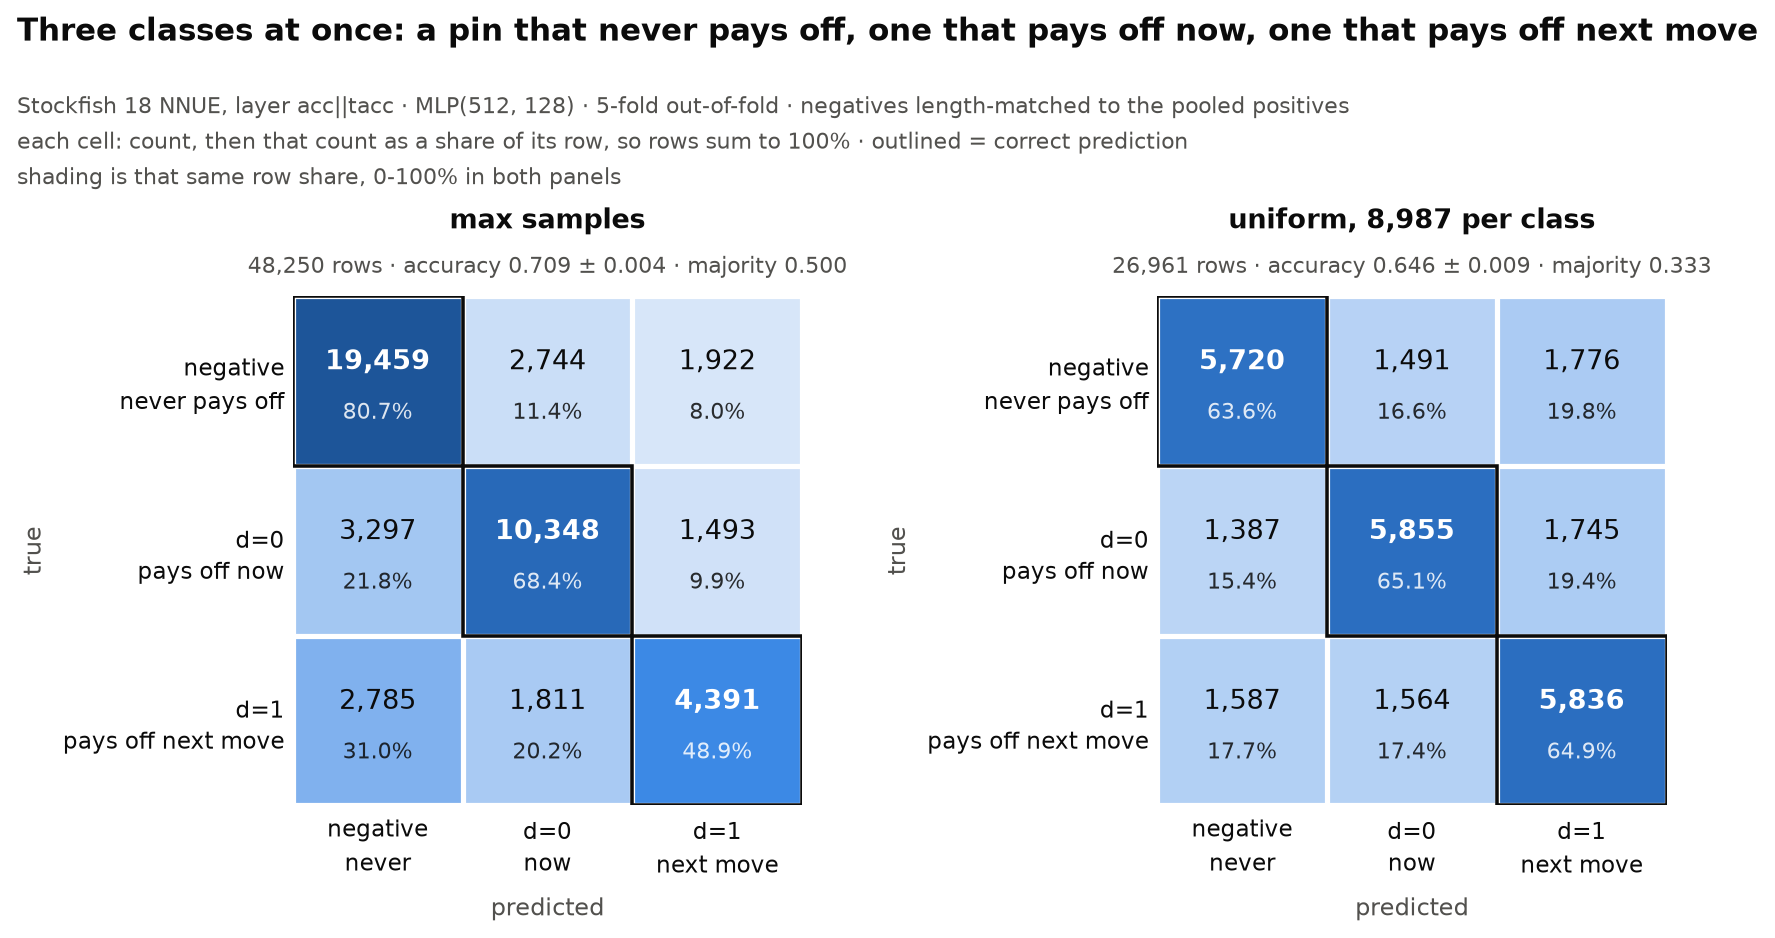

In [9]:
from IPython.display import Image, display
display(Image(filename=str(PLOT)))